# Training Diagnostics — Cousteau nonlinear decoder (adaptive tanh)
Shows loss curves, adaptive λ evolution, gradient norms, and learned latent trajectories.

In [23]:
import os, importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import io

os.environ.setdefault("TORCHDYNAMO_DISABLE", "1")

import msca, msca.models, msca.architectures, msca.utils
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca)
from msca import mSCA

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load data

In [24]:
def load_data(dir_path, f):
    mat_file = io.loadmat(dir_path + f)
    data_array = mat_file["data"]
    mask = mat_file["mask"]
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs   = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()
    return data_array, mask, start_idxs, end_idxs

def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    data_downsamp = data_array[::downsample_factor]
    start_idxs = start_idxs // downsample_factor
    end_idxs   = end_idxs   // downsample_factor
    data_concat = data_downsamp.T
    fr_range = np.ptp(data_concat, axis=1)[:, None]
    data_norm = data_concat / (fr_range + 5)
    data_snm  = data_norm - np.mean(data_norm, axis=1)[:, None]
    fit_data  = np.copy(data_snm.T)
    return [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

fp = "./data/"
m1_data,  m1_mask,  m1_start,  m1_end  = load_data(fp, "Cousteau_interp_cycling_m1_rawRates.mat")
sma_data, sma_mask, sma_start, sma_end = load_data(fp, "Cousteau_interp_cycling_sma_rawRates.mat")

m1_prep  = preprocess(m1_data,  m1_start,  m1_end)
sma_prep = preprocess(sma_data, sma_start, sma_end)

X = {"M1": m1_prep, "SMA": sma_prep}
print(f"M1 trials: {len(X['M1'])},  SMA trials: {len(X['SMA'])}")
print(f"M1 trial shape (example): {X['M1'][0].shape}")

M1 trials: 20,  SMA trials: 20
M1 trial shape (example): (1100, 116)


## 2. Load model and training diagnostics

In [60]:
MODEL_PATH = "./results/Cousteau/msca_nonlinearDecoder_gradient_2.5_tanh_new.pt"
LOSS_PATH  = "./results/Cousteau/losses_nonlinearDecoder_gradient_2.5_tanh_new.npz"

# ── Load checkpoint ──
ckpt = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
meta = ckpt["meta"]
print("Model meta:", meta)

lam_dicts  = ckpt["train_lambda_dicts"]    # {lam_sparse, lam_region, lam_orthog}
grad_dicts = ckpt["train_gradient_dicts"]  # {r_grad, l1_grad}

# ── Load losses ──
losses = mSCA.load_losses(LOSS_PATH)

n_epochs = len(losses["total_loss"])
epochs   = np.arange(n_epochs)
print(f"Epochs recorded: {n_epochs}")

# ── Instantiate and load model ──
model = mSCA(
    n_components      = meta["n_components"],
    n_epochs          = 200,
    linear            = meta["linear"],
    loss_func         = "Gaussian",
    lam_sparse        = "adaptive",
    lam_orthog        = 0.1,
    lam_region        = 0.0,
    decoder_type      = meta["decoder_type"],
    decoder_hidden_size = meta["decoder_hidden_size"],
    decoder_activation  = meta["decoder_activation"],
    post_hoc_epoch    = -1,
    cd_rate           = 0.5,
    cd_mode           = "both",
    filter_len        = 41,
    init              = "unique",
    decoder_init_mode = "pca",
)
model.load(MODEL_PATH, X)
print("Model loaded.")

Model meta: {'lam_sparse': 0.10868965220787678, 'lam_orthog': 32.893707072633305, 'lam_region': 0.0, 'region_weights': {'M1': 0.8072827155633927, 'SMA': 1.3135830209051405}, 'n_components': 40, 'linear': False, 'decoder_type': 'nonlinear', 'decoder_hidden_size': 40, 'decoder_activation': 'tanh'}
Epochs recorded: 5000
Using region-weights = {'M1': 0.8072827155633927, 'SMA': 1.3135830209051405}
Using lam_sparse = adaptive
Using lam_orthog = 32.893707072633305
Using lam_region = 0.0
Model loaded.


## 3. Loss curves

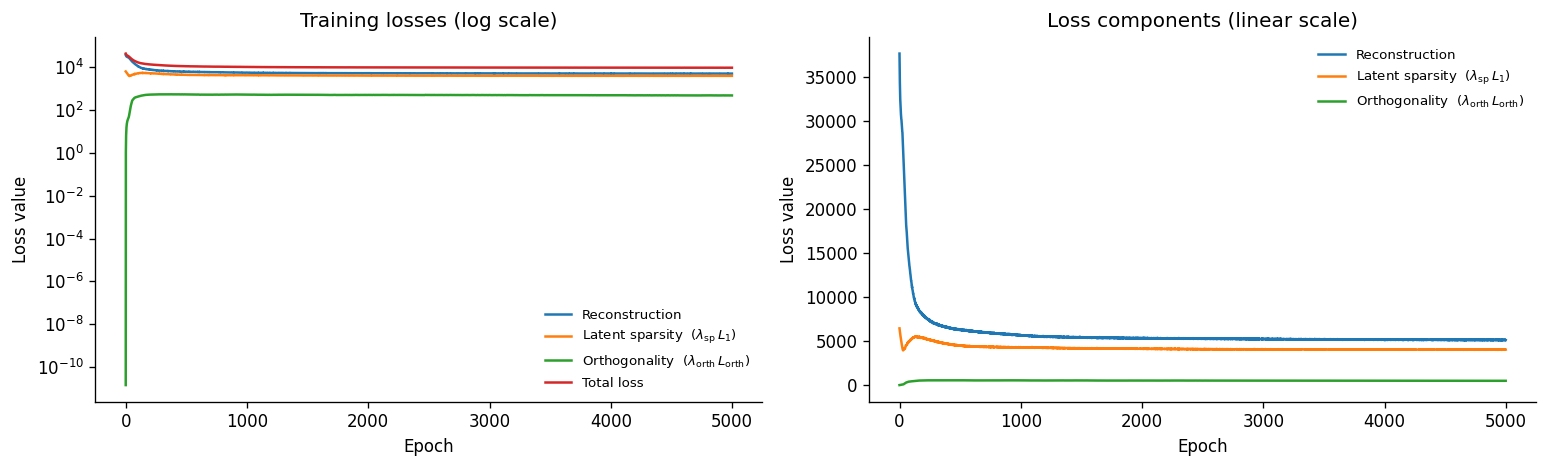

In [61]:
COLORS = {
    "reconstruction":  "#1f77b4",
    "latent_sparsity": "#ff7f0e",
    "orthogonality":   "#2ca02c",
    "region_sparsity": "#9467bd",
    "total_loss":      "#d62728",
}
LABELS = {
    "reconstruction":  r"Reconstruction",
    "latent_sparsity": r"Latent sparsity  ($\lambda_{\mathrm{sp}}\,L_1$)",
    "orthogonality":   r"Orthogonality  ($\lambda_{\mathrm{orth}}\,L_{\mathrm{orth}}$)",
    "region_sparsity": r"Region sparsity",
    "total_loss":      r"Total loss",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: all components on log scale
ax = axes[0]
for key, color in COLORS.items():
    vals = losses[key]
    if np.any(vals > 0):
        ax.plot(epochs, vals, color=color, linewidth=1.5, label=LABELS[key])
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss value")
ax.set_title("Training losses (log scale)")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# Right: individual components (linear, without total)
ax = axes[1]
for key in ["reconstruction", "latent_sparsity", "orthogonality"]:
    ax.plot(epochs, losses[key], color=COLORS[key], linewidth=1.5, label=LABELS[key])
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss value")
ax.set_title("Loss components (linear scale)")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Lambda (λ) evolution during training

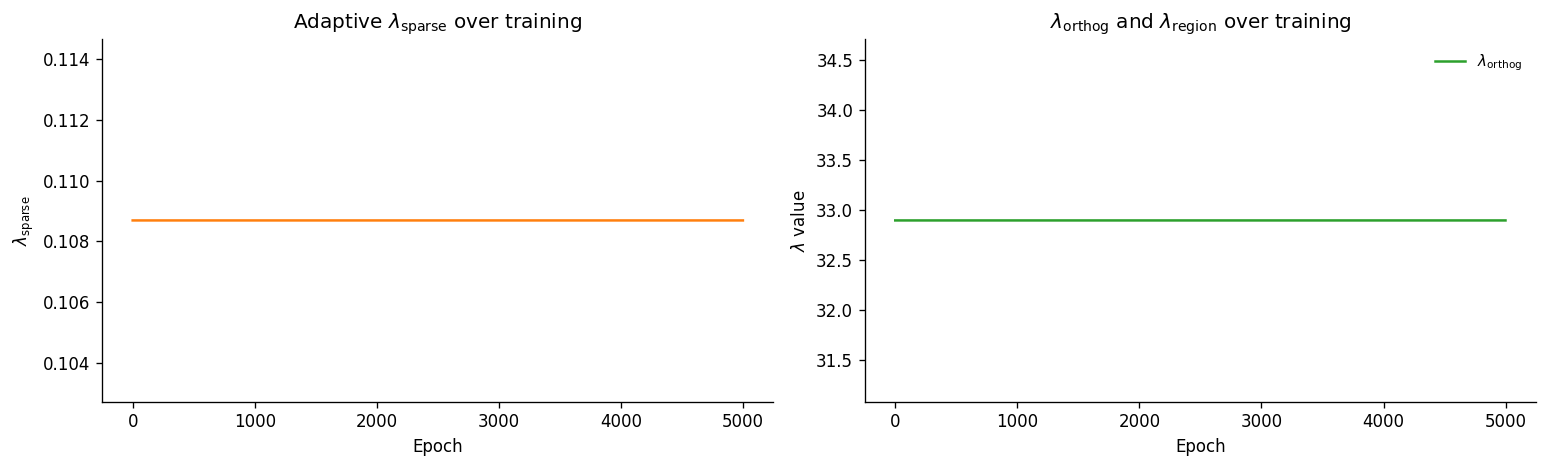

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: adaptive lam_sparse
ax = axes[0]
ax.plot(epochs, lam_dicts["lam_sparse"], color="#ff7f0e", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\lambda_{\mathrm{sparse}}$")
ax.set_title(r"Adaptive $\lambda_{\mathrm{sparse}}$ over training")
ax.spines[["top", "right"]].set_visible(False)

# Right: lam_orthog (fixed per epoch, but verify)
ax = axes[1]
ax.plot(epochs, lam_dicts["lam_orthog"], color="#2ca02c", linewidth=1.5,
        label=r"$\lambda_{\mathrm{orthog}}$")
if np.any(np.array(lam_dicts["lam_region"]) > 0):
    ax.plot(epochs, lam_dicts["lam_region"], color="#9467bd", linewidth=1.5,
            label=r"$\lambda_{\mathrm{region}}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\lambda$ value")
ax.set_title(r"$\lambda_{\mathrm{orthog}}$ and $\lambda_{\mathrm{region}}$ over training")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Encoder gradient norms

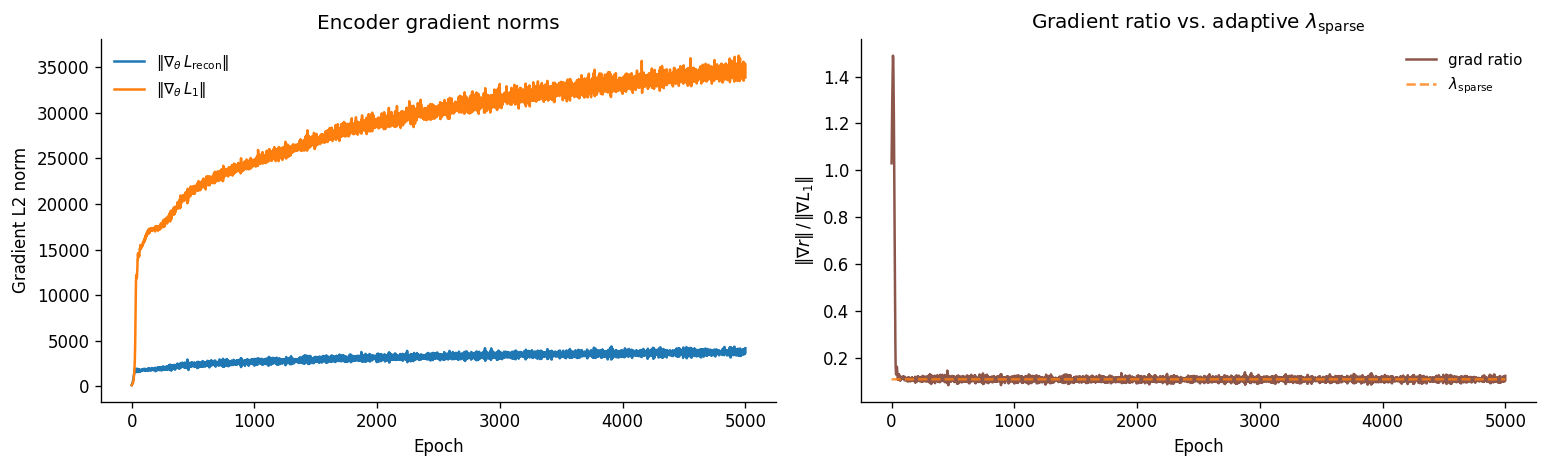

In [63]:
r_grad  = np.array(grad_dicts["r_grad"])
l1_grad = np.array(grad_dicts["l1_grad"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw gradient norms
ax = axes[0]
ax.plot(epochs, r_grad,  color="#1f77b4", linewidth=1.5, label=r"$\|\nabla_{\theta}\, L_{\mathrm{recon}}\|$")
ax.plot(epochs, l1_grad, color="#ff7f0e", linewidth=1.5, label=r"$\|\nabla_{\theta}\, L_1\|$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient L2 norm")
ax.set_title("Encoder gradient norms")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Right: ratio  r_grad / l1_grad  (ideally ≈ lam_sparse)
ax = axes[1]
#ratio = r_grad / np.where(l1_grad > 0, l1_grad, np.nan)
ratio = r_grad / l1_grad
ax.plot(epochs, ratio,                            color="#8c564b", linewidth=1.5, label="grad ratio")
ax.plot(epochs, lam_dicts["lam_sparse"],          color="#ff7f0e", linewidth=1.5,
        linestyle="--", alpha=0.8, label=r"$\lambda_{\mathrm{sparse}}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\|\nabla r\|\,/\,\|\nabla L_1\|$")
ax.set_title(r"Gradient ratio vs. adaptive $\lambda_{\mathrm{sparse}}$")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Combined summary panel

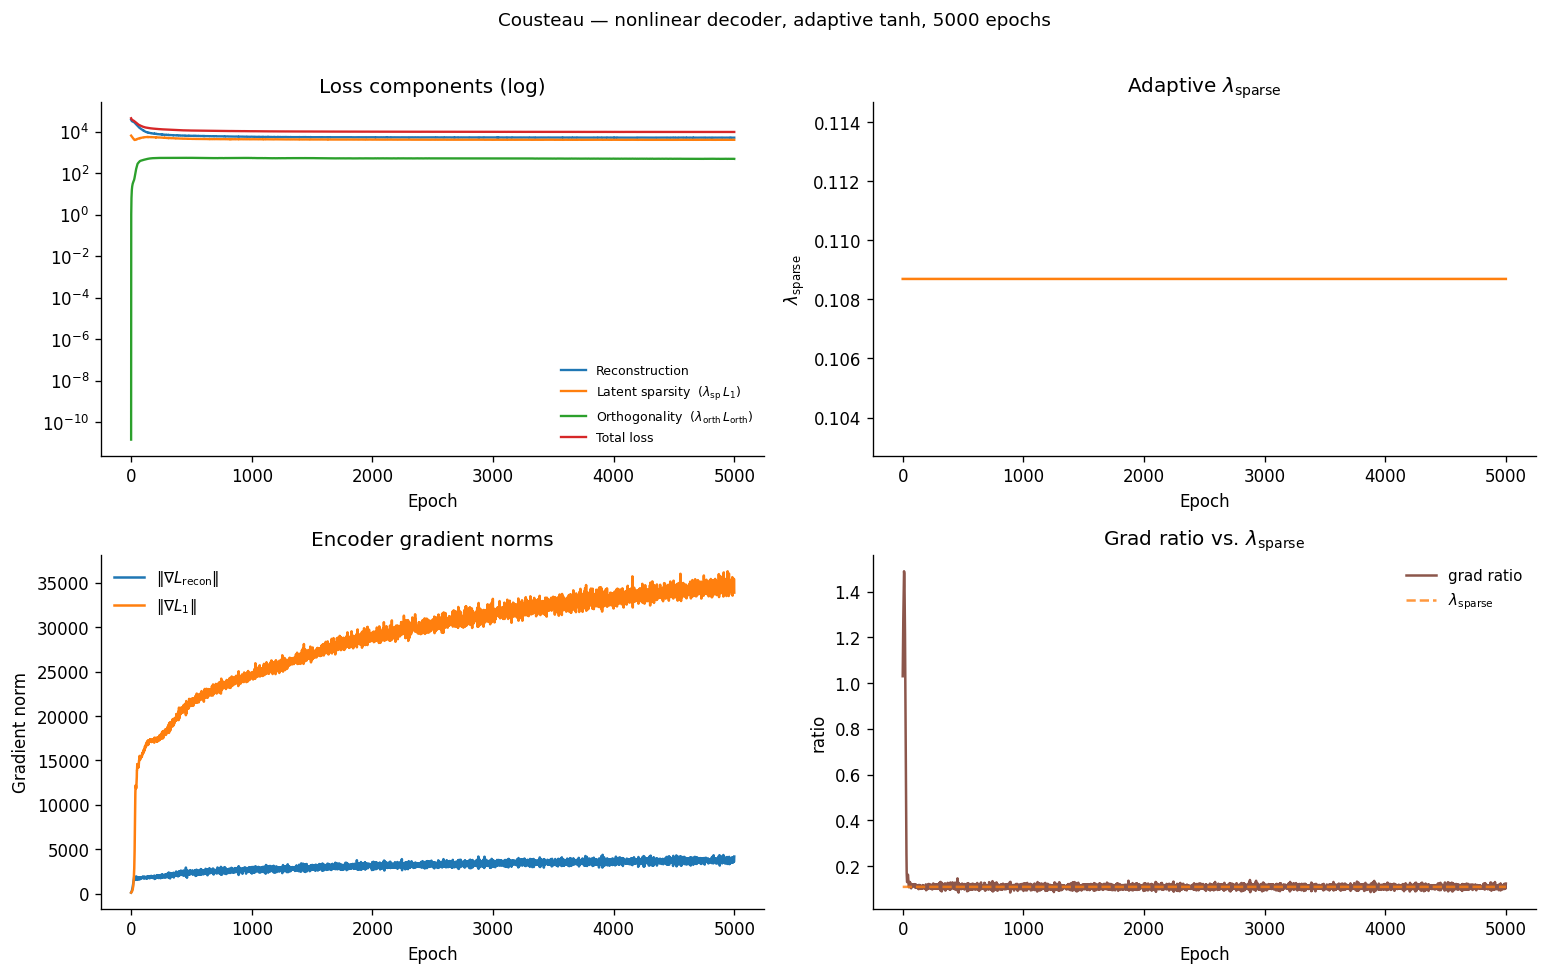

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── top-left: total loss + components ──────────────────────────────────────
ax = axes[0, 0]
for key in ["reconstruction", "latent_sparsity", "orthogonality", "total_loss"]:
    ax.plot(epochs, losses[key], color=COLORS[key], linewidth=1.4, label=LABELS[key])
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_title("Loss components (log)")
ax.legend(frameon=False, fontsize=7.5)
ax.spines[["top", "right"]].set_visible(False)

# ── top-right: adaptive lam_sparse ────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs, lam_dicts["lam_sparse"], color="#ff7f0e", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\lambda_{\mathrm{sparse}}$")
ax.set_title(r"Adaptive $\lambda_{\mathrm{sparse}}$")
ax.spines[["top", "right"]].set_visible(False)

# ── bottom-left: encoder gradient norms ───────────────────────────────────
ax = axes[1, 0]
ax.plot(epochs, r_grad,  color="#1f77b4", linewidth=1.5, label=r"$\|\nabla L_{\mathrm{recon}}\|$")
ax.plot(epochs, l1_grad, color="#ff7f0e", linewidth=1.5, label=r"$\|\nabla L_1\|$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient norm")
ax.set_title("Encoder gradient norms")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── bottom-right: gradient ratio vs lam_sparse ────────────────────────────
ax = axes[1, 1]
ax.plot(epochs, ratio,                   color="#8c564b", linewidth=1.5, label="grad ratio")
ax.plot(epochs, lam_dicts["lam_sparse"], color="#ff7f0e", linewidth=1.5,
        linestyle="--", alpha=0.8, label=r"$\lambda_{\mathrm{sparse}}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"ratio")
ax.set_title(r"Grad ratio vs. $\lambda_{\mathrm{sparse}}$")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Cousteau — nonlinear decoder, adaptive tanh, 5000 epochs", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("./results/Cousteau/training_diagnostics_summary.pdf", bbox_inches="tight")
plt.show()

## 7. Latent trajectories
Each subplot is one latent dimension. M1 latents in blue, SMA in orange. First 20 trials shown.

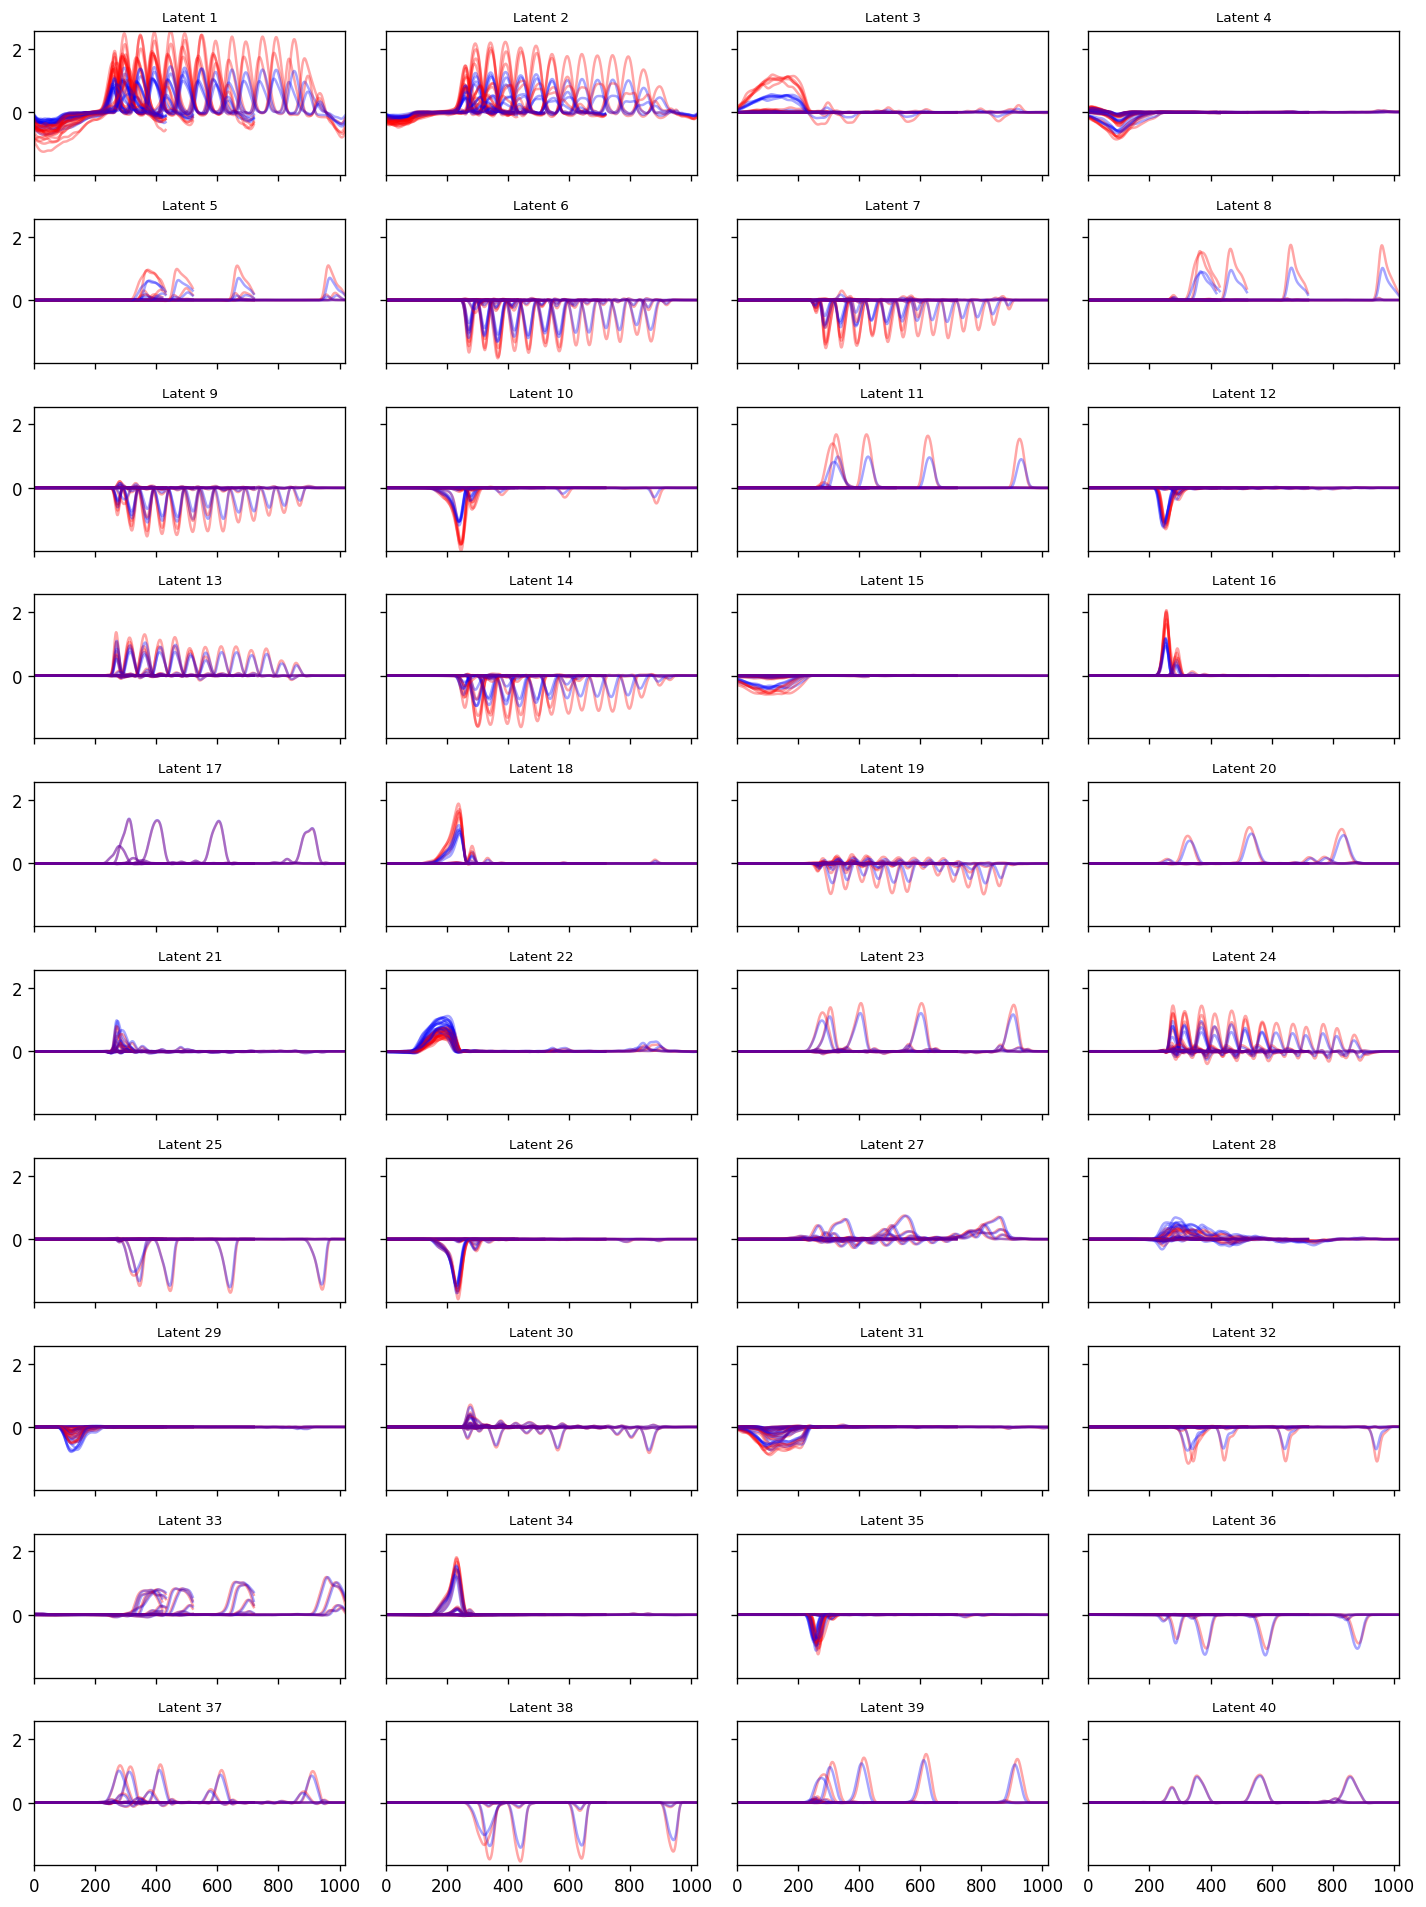

In [65]:
Z = model.transform(X)

n_components = 40
# there are 20 trails for each region
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components): # plot each component in its own subplot
    ax = axs[i // 4, i % 4]
    for j in range(n_trials): # plot 20 trails per region on the same subplot
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()

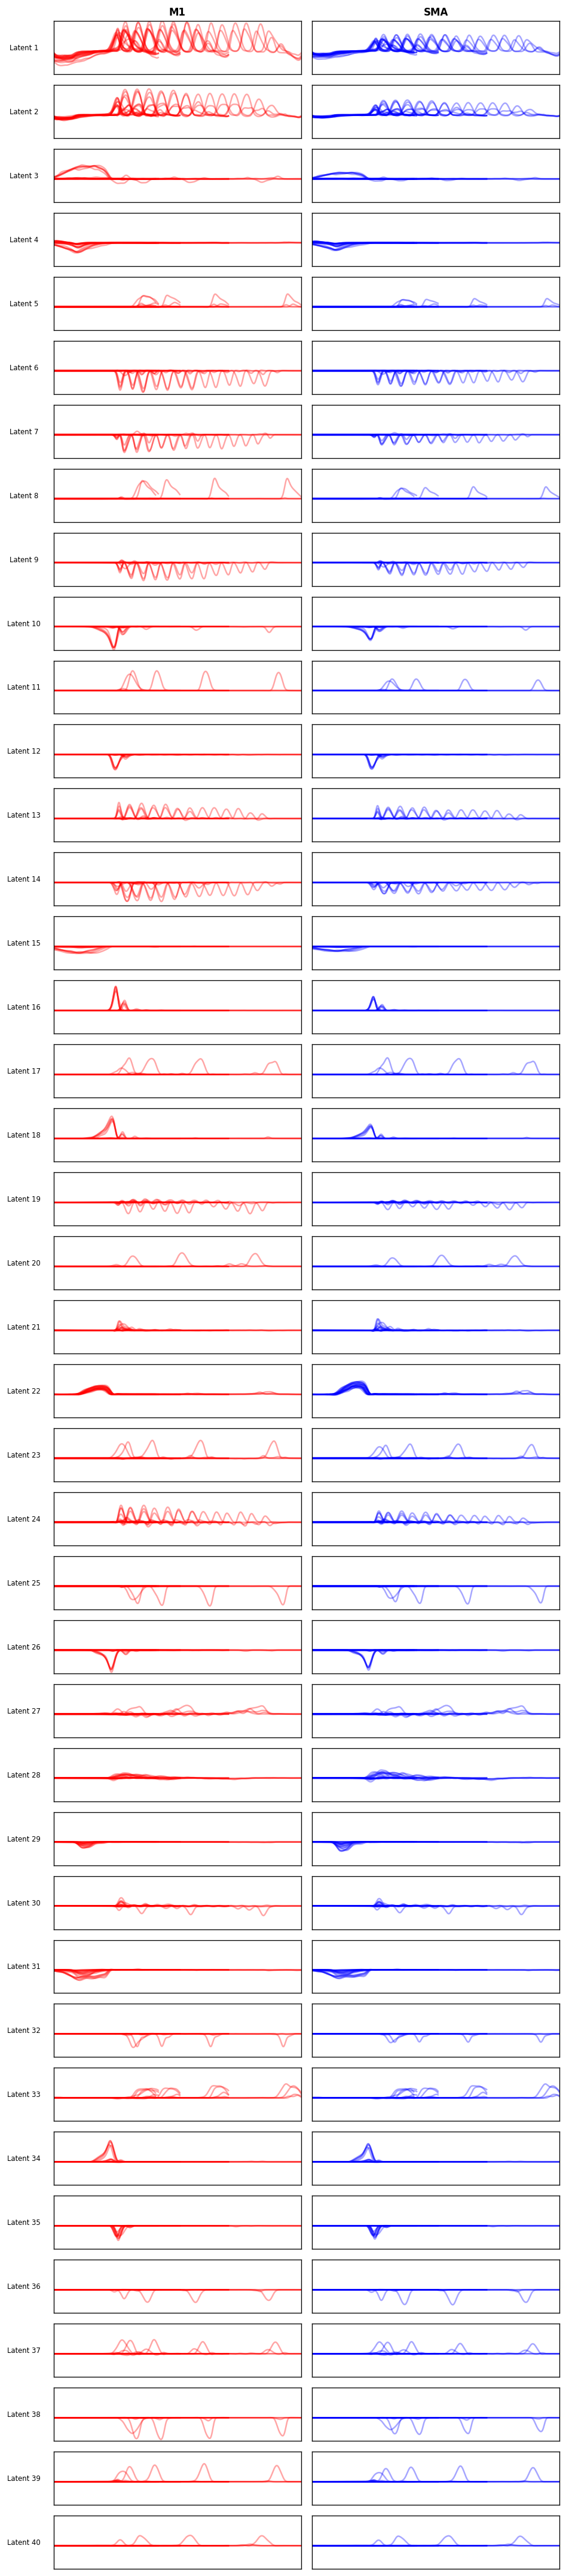

In [67]:
n_components = 40
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

# Global x-range
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(n_components, 2, figsize=(8, n_components * 0.9),
                        sharex=True, sharey=True)

for i in range(n_components):
    ax_m1  = axs[i, 0]
    ax_sma = axs[i, 1]

    for j in range(n_trials):
        ax_m1.plot( Z['M1'][j][:,  i], c='r', alpha=0.35)
        ax_sma.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)

    for ax in [ax_m1, ax_sma]:
        ax.set_xlim(0, max_t - 1)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([])
        ax.set_yticks([])

    ax_m1.set_ylabel(f'Latent {i+1}', fontsize=7, rotation=0, labelpad=30, va='center')

axs[0, 0].set_title('M1',  fontsize=10, fontweight='bold')
axs[0, 1].set_title('SMA', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [69]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import CCA

# Z is already computed from model.transform(X)
# Concatenate trials while respecting trial boundaries (no lag across trials)

LAG = 3  # number of time steps to lag

def build_lagged_pairs(Z_src_list, Z_tgt_list, k, j, lag):
    """
    For each trial, build (Z_src^k lagged, Z_tgt^j current) pairs.
    Lags never cross trial boundaries.
    """
    X_parts, Y_parts = [], []
    for src, tgt in zip(Z_src_list, Z_tgt_list):
        T = min(src.shape[0], tgt.shape[0])
        if T <= lag:
            continue
        X_parts.append(src[: T - lag, k])
        Y_parts.append(tgt[lag : T,   j])
    return np.array(np.concatenate(X_parts)), np.array(np.concatenate(Y_parts))

n_comp = meta["n_components"]
n_trials = len(Z["M1"])


In [70]:
def lagged_r2_matrix(Z_src_list, Z_tgt_list, n_comp, lag):
    """
    Returns (n_comp, n_comp) matrix of R² values.
    Entry [k, j]: how well Z_src^k(t) predicts Z_tgt^j(t+lag).
    """
    R2 = np.zeros((n_comp, n_comp))
    for k in range(n_comp):
        for j in range(n_comp):
            x, y = build_lagged_pairs(Z_src_list, Z_tgt_list, k, j, lag)
            # fit linear regression
            x = x.reshape(-1, 1)
            reg = LinearRegression().fit(x, y)
            ss_res = np.sum((y - reg.predict(x)) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            R2[k, j] = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return R2

print("Computing M1 → SMA lagged R²...")
R2_m1_to_sma = lagged_r2_matrix(Z["M1"], Z["SMA"], n_comp, lag=LAG)

print("Computing SMA → M1 lagged R²...")
R2_sma_to_m1 = lagged_r2_matrix(Z["SMA"], Z["M1"], n_comp, lag=LAG)

print(f"M1→SMA: mean R²={R2_m1_to_sma.mean():.4f}, max={R2_m1_to_sma.max():.4f}")
print(f"SMA→M1: mean R²={R2_sma_to_m1.mean():.4f}, max={R2_sma_to_m1.max():.4f}")


Computing M1 → SMA lagged R²...
Computing SMA → M1 lagged R²...
M1→SMA: mean R²=0.0318, max=0.9997
SMA→M1: mean R²=0.0321, max=0.9999


In [71]:
def granger_matrix(Z_src_list, Z_tgt_list, n_comp, lag):
    """
    Returns (n_comp, n_comp) matrix of Granger F-statistics.
    Tests whether Z_src^k lags improve AR prediction of Z_tgt^j
    beyond Z_tgt^j's own past.
    """
    F_mat = np.zeros((n_comp, n_comp))
    p_mat = np.ones((n_comp,  n_comp))

    # Build each target's own-past regressors
    for j in range(n_comp):
        # restricted model: Z_tgt^j(t) ~ Z_tgt^j(t-1..lag)
        Y_parts, Xr_parts, Xf_parts_list = [], [], {k: [] for k in range(n_comp)}
        for trial in zip(Z_src_list, Z_tgt_list):
            src, tgt = trial
            T = min(src.shape[0], tgt.shape[0])
            if T <= lag:
                continue
            y = tgt[lag:T, j]
            xr = np.stack([tgt[lag - l - 1 : T - l - 1, j] for l in range(lag)], axis=1)
            Y_parts.append(y)
            Xr_parts.append(xr)
            for k in range(n_comp):
                xk = src[lag - 1 : T - 1, k].reshape(-1, 1)
                Xf_parts_list[k].append(xk)

        Y  = np.concatenate(Y_parts)
        Xr = np.concatenate(Xr_parts, axis=0)
        n  = len(Y)

        # restricted model residuals
        beta_r = np.linalg.lstsq(Xr, Y, rcond=None)[0]
        rss_r  = np.sum((Y - Xr @ beta_r) ** 2)

        for k in range(n_comp):
            xk = np.concatenate(Xf_parts_list[k], axis=0)
            Xf = np.concatenate([Xr, xk], axis=1)
            beta_f = np.linalg.lstsq(Xf, Y, rcond=None)[0]
            rss_f  = np.sum((Y - Xf @ beta_f) ** 2)

            # F-test: 1 extra regressor (xk), df = n - lag - 1
            df1, df2 = 1, n - lag - 1
            F = ((rss_r - rss_f) / df1) / (rss_f / df2) if rss_f > 0 else 0.0
            p = 1 - stats.f.cdf(F, df1, df2)
            F_mat[k, j] = F
            p_mat[k, j] = p

    return F_mat, p_mat

print("Computing Granger M1 → SMA...")
F_m1_to_sma, p_m1_to_sma = granger_matrix(Z["M1"], Z["SMA"], n_comp, lag=LAG)

print("Computing Granger SMA → M1...")
F_sma_to_m1, p_sma_to_m1 = granger_matrix(Z["SMA"], Z["M1"], n_comp, lag=LAG)


Computing Granger M1 → SMA...
Computing Granger SMA → M1...


In [74]:
# Concatenate all trials into full time series (no lag needed for CCA)
Z_m1_full  = np.concatenate([t for t in Z["M1"]],  axis=0)   # (T_total, n_comp)
Z_sma_full = np.concatenate([t for t in Z["SMA"]], axis=0)

# Align lengths
T_min = min(Z_m1_full.shape[0], Z_sma_full.shape[0])
Z_m1_full  = Z_m1_full[:T_min]
Z_sma_full = Z_sma_full[:T_min]

n_cca = 10  # number of canonical components to extract
cca = CCA(n_components=n_cca, max_iter=1000)
# or use sklearn's PLSCanonical with regularization
# or reduce to top PCA dims first before CCA
from sklearn.decomposition import PCA
Z_m1_pca  = PCA(n_components=10).fit_transform(Z_m1_full)
Z_sma_pca = PCA(n_components=10).fit_transform(Z_sma_full)
cca = CCA(n_components=5).fit(Z_m1_pca, Z_sma_pca)


/var/folders/lm/hpfh84_s6p71hgkdg87dg0cm0000gn/T/ipykernel_21962/2210141543.py:11: RuntimeWarning: invalid value encountered in log1p
  im = axes[0, 1].imshow(np.log1p(F_m1_to_sma.T), aspect="auto", cmap="hot")
/var/folders/lm/hpfh84_s6p71hgkdg87dg0cm0000gn/T/ipykernel_21962/2210141543.py:27: RuntimeWarning: invalid value encountered in log1p
  im = axes[1, 1].imshow(np.log1p(F_sma_to_m1.T), aspect="auto", cmap="hot")


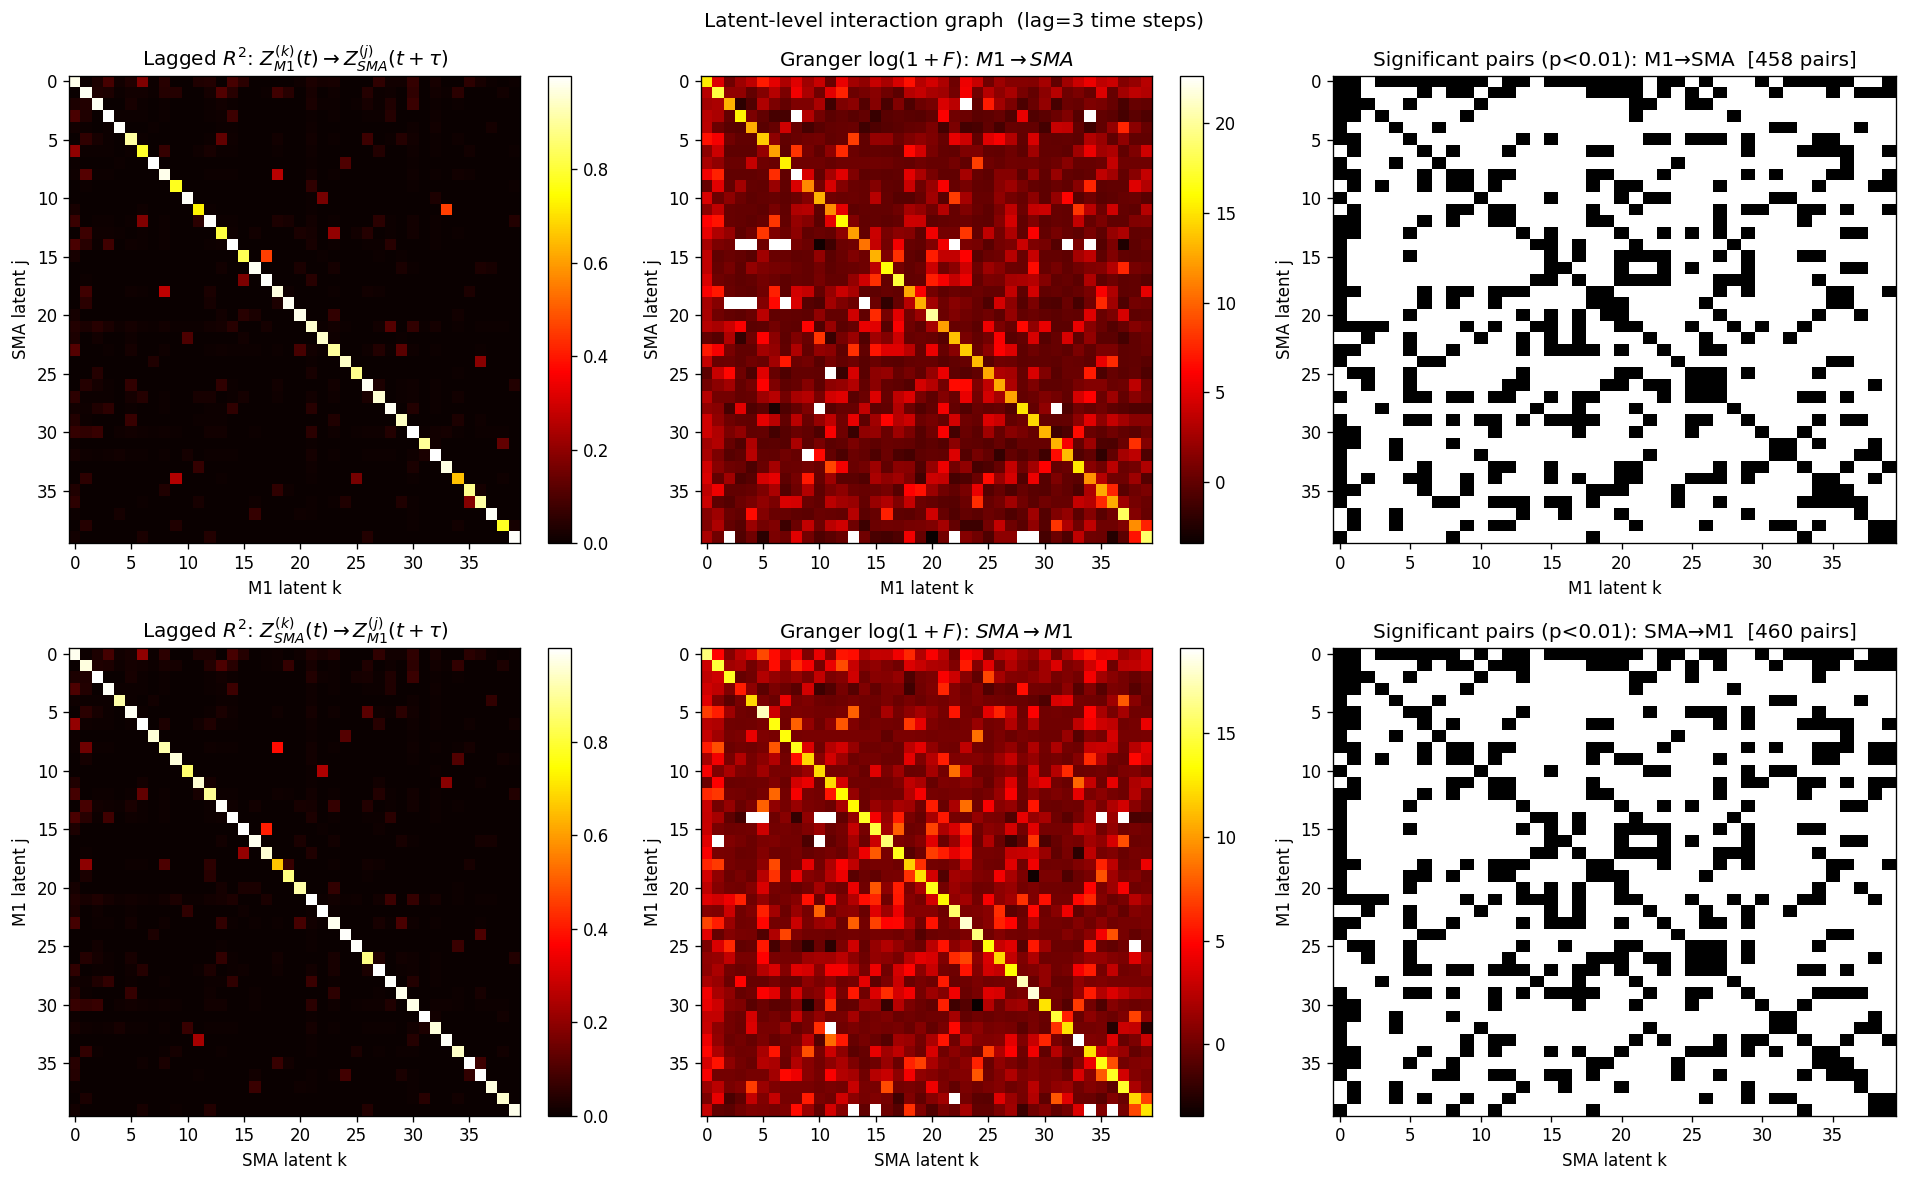

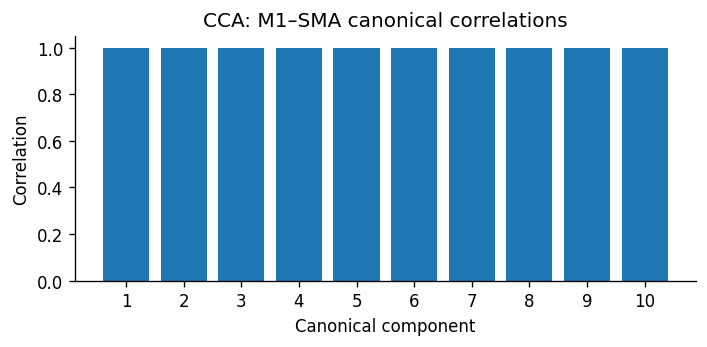

In [75]:
alpha = 0.01  # significance threshold for Granger

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Row 1: M1 → SMA ──────────────────────────────────────────────────────────
im = axes[0, 0].imshow(R2_m1_to_sma.T, aspect="auto", cmap="hot", vmin=0)
axes[0, 0].set_xlabel("M1 latent k"); axes[0, 0].set_ylabel("SMA latent j")
axes[0, 0].set_title(r"Lagged $R^2$: $Z^{(k)}_{M1}(t) \rightarrow Z^{(j)}_{SMA}(t+\tau)$")
plt.colorbar(im, ax=axes[0, 0])

im = axes[0, 1].imshow(np.log1p(F_m1_to_sma.T), aspect="auto", cmap="hot")
axes[0, 1].set_xlabel("M1 latent k"); axes[0, 1].set_ylabel("SMA latent j")
axes[0, 1].set_title(r"Granger $\log(1+F)$: $M1 \rightarrow SMA$")
plt.colorbar(im, ax=axes[0, 1])

sig_m1_sma = (p_m1_to_sma < alpha).T
axes[0, 2].imshow(sig_m1_sma, aspect="auto", cmap="Greys")
axes[0, 2].set_xlabel("M1 latent k"); axes[0, 2].set_ylabel("SMA latent j")
axes[0, 2].set_title(f"Significant pairs (p<{alpha}): M1→SMA  [{sig_m1_sma.sum()} pairs]")

# ── Row 2: SMA → M1 ──────────────────────────────────────────────────────────
im = axes[1, 0].imshow(R2_sma_to_m1.T, aspect="auto", cmap="hot", vmin=0)
axes[1, 0].set_xlabel("SMA latent k"); axes[1, 0].set_ylabel("M1 latent j")
axes[1, 0].set_title(r"Lagged $R^2$: $Z^{(k)}_{SMA}(t) \rightarrow Z^{(j)}_{M1}(t+\tau)$")
plt.colorbar(im, ax=axes[1, 0])

im = axes[1, 1].imshow(np.log1p(F_sma_to_m1.T), aspect="auto", cmap="hot")
axes[1, 1].set_xlabel("SMA latent k"); axes[1, 1].set_ylabel("M1 latent j")
axes[1, 1].set_title(r"Granger $\log(1+F)$: $SMA \rightarrow M1$")
plt.colorbar(im, ax=axes[1, 1])

sig_sma_m1 = (p_sma_to_m1 < alpha).T
axes[1, 2].imshow(sig_sma_m1, aspect="auto", cmap="Greys")
axes[1, 2].set_xlabel("SMA latent k"); axes[1, 2].set_ylabel("M1 latent j")
axes[1, 2].set_title(f"Significant pairs (p<{alpha}): SMA→M1  [{sig_sma_m1.sum()} pairs]")

plt.suptitle(f"Latent-level interaction graph  (lag={LAG} time steps)", fontsize=12)
plt.tight_layout()
plt.savefig("./results/Cousteau/latent_interaction_graph.pdf", bbox_inches="tight")
plt.show()

# ── CCA bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, n_cca + 1), cca_corrs, color="#1f77b4")
ax.set_xlabel("Canonical component")
ax.set_ylabel("Correlation")
ax.set_title("CCA: M1–SMA canonical correlations")
ax.set_xticks(range(1, n_cca + 1))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [76]:
import json
import numpy as np

# Z["M1"] and Z["SMA"] are lists of (T_i, n_components) arrays

save_dict = {
    "metadata": {
        "n_trials":          len(Z["M1"]),
        "n_components":      int(Z["M1"][0].shape[1]),
        "trial_lengths_M1":  [int(t.shape[0]) for t in Z["M1"]],
        "trial_lengths_SMA": [int(t.shape[0]) for t in Z["SMA"]],
    },
    "Z_M1":  [t.tolist() for t in Z["M1"]],   # list of (T_i, n_comp) → nested list
    "Z_SMA": [t.tolist() for t in Z["SMA"]],
}

save_path = "./results/Cousteau/latents_Z.json"
with open(save_path, "w") as f:
    json.dump(save_dict, f)

print(f"Saved to {save_path}")
print(f"  n_trials     : {save_dict['metadata']['n_trials']}")
print(f"  n_components : {save_dict['metadata']['n_components']}")
print(f"  trial lengths M1  : {save_dict['metadata']['trial_lengths_M1']}")
print(f"  trial lengths SMA : {save_dict['metadata']['trial_lengths_SMA']}")


Saved to ./results/Cousteau/latents_Z.json
  n_trials     : 20
  n_components : 40
  trial lengths M1  : [1020, 1020, 1020, 1020, 720, 720, 720, 720, 520, 520, 520, 520, 420, 420, 420, 420, 431, 431, 432, 431]
  trial lengths SMA : [1020, 1020, 1020, 1020, 720, 720, 720, 720, 520, 520, 520, 520, 420, 420, 420, 420, 431, 431, 432, 431]
